# 멀티오믹스_데이터를_활용한_머신러닝_예측_모델_구축
**작성자:** SY  
**작성일:** 2026-04-27
---

## 1. 서론
 본 분석은 멀티오믹스 통합 데이터셋을 활용하여 유전자 및 대사체 지표가 질환 발병에 미치는 영향을 분석하고, Random Forest 모델을 통해 발병 여부를 예측하는 것을 목적으로 하는 실습 과정임.

## 2. 데이터 준비 및 패키지 설정
 본 분석을 위해 터미널을 통하여 아래의 패키지를 설치함.

In [1]:
# pip3 install pandas scikit-learn matplotlib seaborn ---break-system-packages

 필요한 라이브러리를 로드하고 분석 환경 설정을 진행함.

In [2]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

# 데이터 로드
df = pd.read_csv('MultiOmics_Final_Dataset.csv', index_col=0)
print(f"데이터 구조: {df.shape}")

데이터 구조: (12, 45)


## 3. 탐색적 데이터 분석 (EDA)
변수 간의 상관성 확인을 통해 데이터의 타당성을 검토함.

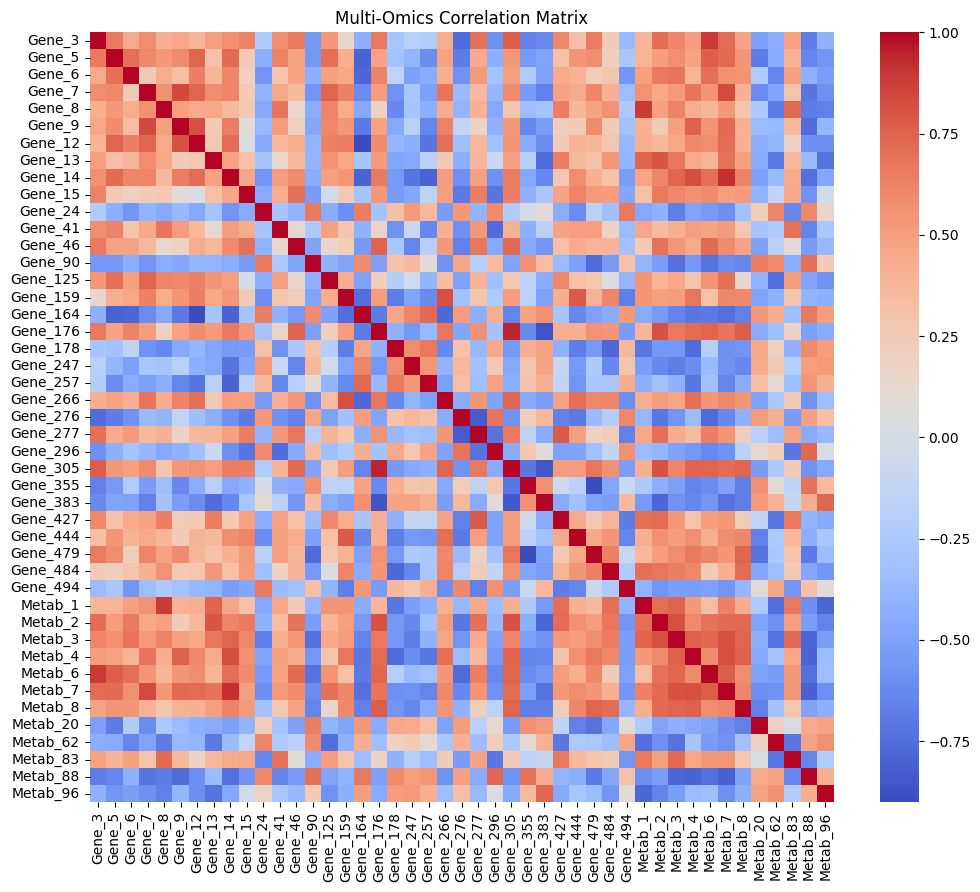

In [3]:
plt.figure(figsize=(12, 10))  # 그래프 figure의 사이즈 (가로 12, 세로 10)
corr = df.corr()  # 피어슨 상관계수 계산 (-1: 반비례, 1: 정비례)
sns.heatmap(corr, annot=False, cmap='coolwarm')  # 숫자 제거 및 색상 선정 (+: 빨간색, -: 파란색)
plt.title("Multi-Omics Correlation Matrix")
plt.show()

본 데이터셋은 핵심 신호가 뚜렷하고 오믹스 간 상호작용이 확인된 양질의 데이터로, 머신러닝을 통한 변수 최적화를 거칠 경우 단일 오믹스 대비 정밀한 예측 모델 구축이 가능할 것임.

## 4. 머신러닝 모델 구축
 분석의 재현성을 위해 데이터를 8:2로 분할하고, Random Forest 모델을 학습시킴.
 + 충분한 학습을 위해 데이터의 80%는 학습, 20%는 결과 용도로 분할.
 + 대용량 멀티오믹스 데이터의 단순 비례하지 않는 복잡한 관계를 효과적으로 학습하며, 변수 중요도 산출을 통해 노이즈 변수를 배제하고 핵심 바이오마커를 식별하는 데 최적화 모델이기 때문에 해당 모델을 사용.

In [4]:
 # 라벨링: 인덱스에 'DIS'가 포함되면 1(질환), 아니면 0(정상)
 # 그렇게 만든 0과 1의 리스트를 Target이라는 새로운 열로 df에 합침.
df['Target'] = [1 if 'DIS' in idx else 0 for idx in df.index]
 # 질환과 정상의 수가 각각 얼마인지 확인 (비율 확인)
print(df['Target'].value_counts())  # 0과 1이 각각 6, 6으로 표본이 적지만, 머신러닝의 방법론과 파이파라인을 구축하는 학습 중이므로 신경쓰지 않음.

 # df에서 Target 열을 삭제하라 (X: 훈련문제)
X = df.drop('Target', axis=1)  # df.drop(): 특정 행이나 열을 삭제  # axis=1(세로 열), axis=0(가로 행)
 # 전체 df에서 Target 열만 선택 (y: 실전 문제)
y = df['Target']

 # 데이터 분할 - X, y를 연습용과 시험용으로 각각 2개씩 나눔.(총 4개)
 # 전체 데이터 중 20%를 실전용으로 뺴둠.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)  # random_state=123 -> 난수 번호: 123  # stratify=y -> y의 비율을 확인하여 질환과 정상 비율을 5:5로 유지 (충화 추출) 

 # 랜덤 포레스트 모델 생성 및 학습
model = RandomForestClassifier(n_estimators=100, random_state=123, n_jobs=-1)  # n_estimators=100 -> 독립적인 개별 추정기의 개수 설정(100개)  # n_jobs=-1 -> 병렬 연산
 # 연습용 입력 변수(X_train)와 타깃 라벨(y_train) 간의 조건부 확률 분포를 학습
model.fit(X_train, y_train) 

Target
0    6
1    6
Name: count, dtype: int64


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric